# **RIDGE regression - Training Window**

Marek Šugár

In [1]:
import sys
import os

sys.path.append(os.path.abspath(".."))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from DataFramePrep import generate_TrainingDataFrame

# Metrics to measure successfulness
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.preprocessing import StandardScaler

# ML Stuff
from sklearn.linear_model import Lasso

# Ignore warnings
import warnings

warnings.filterwarnings("ignore")


In [2]:
TrainingDataFrame, tickers, historic_columns, StockDataDatabase = generate_TrainingDataFrame()

In [3]:
TrainingDataFrame["Time_flow"] = np.arange(1, len(TrainingDataFrame)+1)
historic_columns.append("Time_flow")

# **LASSO regression**

In [4]:
performance_tracker = {}
performance_simple = {}
model_dominance = {}

for ticker in tickers["Ticker"]:
    Stock_Data = pd.read_sql(f"SELECT * FROM StockData WHERE Ticker='{ticker}' AND Date>='2017-09-14'", con=StockDataDatabase, parse_dates=["Date"])
    
    Stock_Data = pd.merge(Stock_Data, TrainingDataFrame, left_on="Date", right_on="Date")

    Stock_Data["Target"] = Stock_Data["Close"]
    Stock_Data = Stock_Data.dropna().reset_index(drop=True)

    training_length = 3 # Days
    prediction_length = 1 # Days

    performance_tracker[ticker] = []
    performance_simple[ticker] = []
    model_dominance[ticker] = []

    MAPEs = []
    AccuracyToSimple = []
    dominance_dates = []
    for window_start in range(len(Stock_Data) - (training_length + prediction_length)):
        if window_start + training_length + prediction_length > len(TrainingDataFrame):
            continue
            
        scaler = StandardScaler()

        Training_Features = scaler.fit_transform(TrainingDataFrame[historic_columns].iloc[window_start:window_start+training_length])
        Training_Target = Stock_Data["Target"].iloc[window_start:window_start+training_length]
    
        Test_Features = scaler.transform(TrainingDataFrame[historic_columns].iloc[window_start+training_length:window_start+training_length+prediction_length])
        Test_Target = Stock_Data["Target"].iloc[window_start+training_length:window_start+training_length+prediction_length]

        MODEL = Lasso(alpha=4.579999999999998, max_iter=3000)

        MODEL.fit(Training_Features, Training_Target)
    
        prediction = MODEL.predict(Test_Features)

        AccuracyToSimple.append(mean_absolute_percentage_error(Test_Target, prediction) <= (mean_absolute_percentage_error(Test_Target, [Training_Target.iloc[-1]])))
        MAPEs.append(100*mean_absolute_percentage_error(Test_Target, prediction))

        if mean_absolute_percentage_error(Test_Target, prediction) <= mean_absolute_percentage_error(Test_Target, [Training_Target.iloc[-1]]):
            dominance_dates.append(str(Stock_Data["Date"].iloc[window_start+training_length+prediction_length].date()))                                                        

        #print(ticker, 100*mean_absolute_percentage_error(Test_Target, prediction))    
        
    performance_tracker[ticker] = MAPEs.copy()
    performance_simple[ticker] = AccuracyToSimple.copy()
    model_dominance[ticker] = dominance_dates.copy()


In [5]:
np.mean([np.mean(i) for i in performance_simple.values()])

np.float64(0.38501578501578504)

In [6]:
performance_tracker = pd.DataFrame(performance_tracker).astype("float")

# MEANS & RANGE Metrics
mean_performances = {}
range_performances = {}
for ticker in tickers["Ticker"]:
    mean_performances[ticker] = np.mean(performance_tracker[ticker])
    range_performances[ticker] = np.max(performance_tracker[ticker]) - np.min(performance_tracker[ticker])

mean_performances = dict(sorted(mean_performances.items(), key=lambda x: x[1]))
range_performances = dict(sorted(range_performances.items(), key=lambda x: x[1]))

In [7]:
np.mean(list(mean_performances.values()))

np.float64(2.1473816650349415)

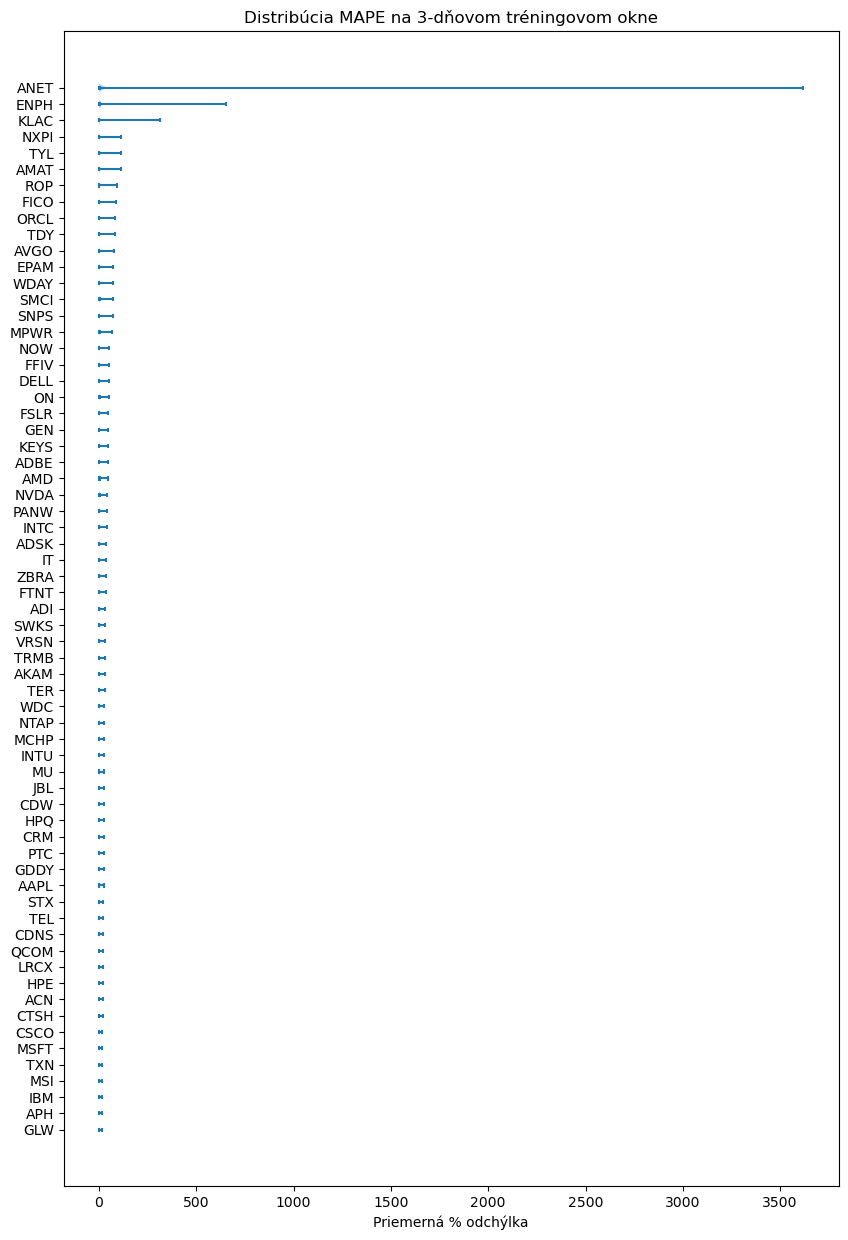

In [8]:
plt.figure(figsize=(10, 15))
plt.violinplot(performance_tracker[list(range_performances.keys())], showmeans=True, orientation="horizontal")

plt.xlabel("Priemerná % odchýlka")
plt.yticks(range(1, 66), list(range_performances.keys()))

plt.title(f"Distribúcia MAPE na {training_length}-dňovom tréningovom okne")

plt.show()

In [9]:
mean_performances

{'ROP': np.float64(1.3410589039306076),
 'MSI': np.float64(1.3490512944459665),
 'CSCO': np.float64(1.3719575337793928),
 'IBM': np.float64(1.3815536330925373),
 'VRSN': np.float64(1.4380948565794343),
 'CTSH': np.float64(1.4754949536984807),
 'ACN': np.float64(1.492088025517766),
 'MSFT': np.float64(1.4975625305959848),
 'APH': np.float64(1.5088674327022014),
 'TEL': np.float64(1.6082954442484667),
 'TDY': np.float64(1.6095079475632812),
 'AKAM': np.float64(1.6289705457719927),
 'TXN': np.float64(1.6544642910406637),
 'ORCL': np.float64(1.663778500016643),
 'GLW': np.float64(1.671104835685652),
 'FFIV': np.float64(1.6801667843300365),
 'CDW': np.float64(1.6898692950266476),
 'IT': np.float64(1.708250699599683),
 'AAPL': np.float64(1.7087452959291145),
 'TYL': np.float64(1.7168145920657625),
 'KEYS': np.float64(1.7548736591314007),
 'GEN': np.float64(1.7809857988615876),
 'ADI': np.float64(1.820774396524068),
 'GDDY': np.float64(1.8409659052706768),
 'PTC': np.float64(1.897777692049769

# **Date-wise model dominance over naive**

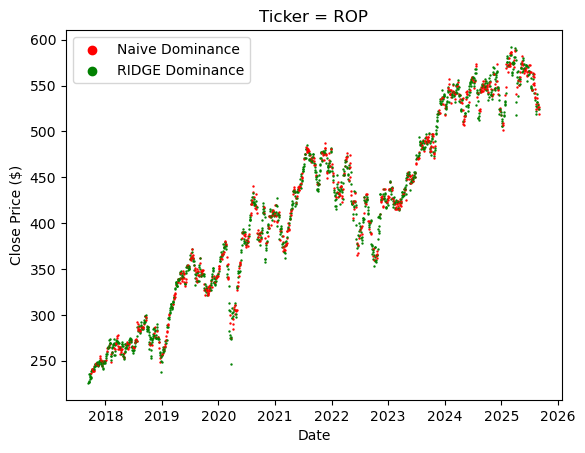

In [10]:
colors = {'A':'red', 'B':'green'}
for label, color in colors.items():
    plt.scatter([], [], c=color, label=label)  # invisible points for legend

ticker = "ROP"
Stock_Data = pd.read_sql(f"SELECT * FROM StockData WHERE Ticker='{ticker}' AND Date>='2017-09-14'", con=StockDataDatabase, parse_dates=["Date"])
    
for i in range(len(Stock_Data)):
    date = Stock_Data.iloc[i]["Date"]
    close_price = Stock_Data.iloc[i]["Close"]

    if str(Stock_Data.iloc[i]["Date"].date()) in model_dominance[f"{ticker}"]:
        plt.scatter(date, close_price, c="red", s=0.5)
    else:
        plt.scatter(date, close_price, c="green", s=0.5)

plt.legend(title="Category")
plt.legend(["Naive Dominance", "RIDGE Dominance"])
plt.title(f"Ticker = {ticker}")

plt.xlabel("Date")
plt.ylabel("Close Price ($)")

plt.show()

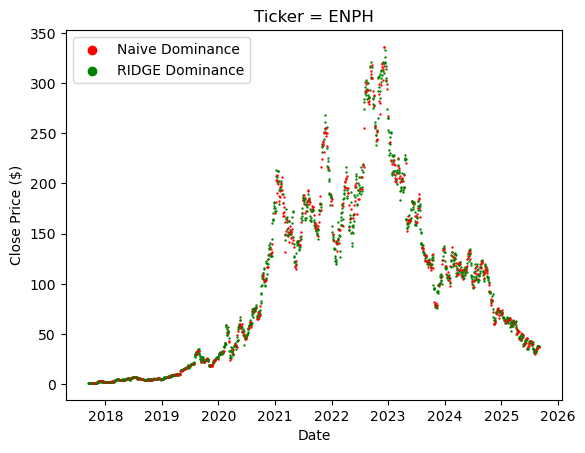

In [10]:
colors = {'A':'red', 'B':'green'}
for label, color in colors.items():
    plt.scatter([], [], c=color, label=label)  # invisible points for legend

ticker = "ENPH"
Stock_Data = pd.read_sql(f"SELECT * FROM StockData WHERE Ticker='{ticker}' AND Date>='2017-09-14'", con=StockDataDatabase, parse_dates=["Date"])
    
for i in range(len(Stock_Data)):
    date = Stock_Data.iloc[i]["Date"]
    close_price = Stock_Data.iloc[i]["Close"]

    if str(Stock_Data.iloc[i]["Date"].date()) in model_dominance[f"{ticker}"]:
        plt.scatter(date, close_price, c="red", s=0.5)
    else:
        plt.scatter(date, close_price, c="green", s=0.5)

plt.legend(title="Category")
plt.legend(["Naive Dominance", "RIDGE Dominance"])
plt.title(f"Ticker = {ticker}")

plt.xlabel("Date")
plt.ylabel("Close Price ($)")

plt.show()

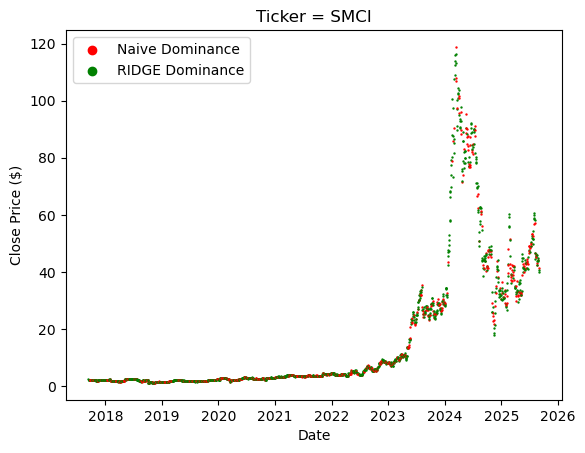

In [11]:
colors = {'A':'red', 'B':'green'}
for label, color in colors.items():
    plt.scatter([], [], c=color, label=label)  # invisible points for legend

ticker = "SMCI"
Stock_Data = pd.read_sql(f"SELECT * FROM StockData WHERE Ticker='{ticker}' AND Date>='2017-09-14'", con=StockDataDatabase, parse_dates=["Date"])
    
for i in range(len(Stock_Data)):
    date = Stock_Data.iloc[i]["Date"]
    close_price = Stock_Data.iloc[i]["Close"]

    if str(Stock_Data.iloc[i]["Date"].date()) in model_dominance[f"{ticker}"]:
        plt.scatter(date, close_price, c="red", s=0.5)
    else:
        plt.scatter(date, close_price, c="green", s=0.5)

plt.legend(title="Category")
plt.legend(["Naive Dominance", "RIDGE Dominance"])
plt.title(f"Ticker = {ticker}")

plt.xlabel("Date")
plt.ylabel("Close Price ($)")

plt.show()

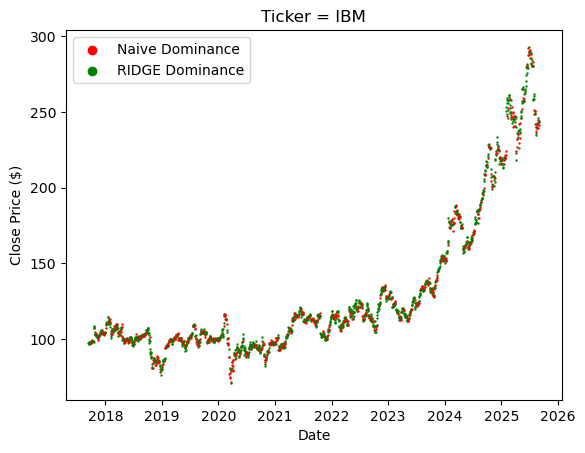

In [12]:
colors = {'A':'red', 'B':'green'}
for label, color in colors.items():
    plt.scatter([], [], c=color, label=label)  # invisible points for legend

ticker = "IBM"
Stock_Data = pd.read_sql(f"SELECT * FROM StockData WHERE Ticker='{ticker}' AND Date>='2017-09-14'", con=StockDataDatabase, parse_dates=["Date"])
    
for i in range(len(Stock_Data)):
    date = Stock_Data.iloc[i]["Date"]
    close_price = Stock_Data.iloc[i]["Close"]

    if str(Stock_Data.iloc[i]["Date"].date()) in model_dominance[f"{ticker}"]:
        plt.scatter(date, close_price, c="red", s=0.5)
    else:
        plt.scatter(date, close_price, c="green", s=0.5)

plt.legend(title="Category")
plt.legend(["Naive Dominance", "RIDGE Dominance"])
plt.title(f"Ticker = {ticker}")

plt.xlabel("Date")
plt.ylabel("Close Price ($)")

plt.show()

# **Analysis of dominance in detail**

In [11]:
# COVID
# We perform analysis of precision between February and March 2020 -> Covid recession

# Number of trading days -> 41 days
trading_days = TrainingDataFrame[(TrainingDataFrame["Date"] >= "2020-02-01") & (TrainingDataFrame["Date"] <= "2020-03-31")]["Date"].values
trading_days = [str(i).split("T")[0] for i in trading_days]

covid_dominances = {}

for ticker in tickers["Ticker"]:
    counter = 0
    for day in model_dominance[ticker]:
        if day in trading_days:
            counter += 1
    covid_dominances[ticker] = counter*100 / len(trading_days)

print(np.mean(list(covid_dominances.values())))

41.613508442776734


In [12]:
sorted(covid_dominances.items(), key=lambda x: x[1], reverse=True)

[('KEYS', 58.53658536585366),
 ('QCOM', 58.53658536585366),
 ('CSCO', 51.21951219512195),
 ('EPAM', 51.21951219512195),
 ('HPQ', 51.21951219512195),
 ('IBM', 51.21951219512195),
 ('INTC', 51.21951219512195),
 ('ORCL', 51.21951219512195),
 ('SWKS', 51.21951219512195),
 ('TXN', 51.21951219512195),
 ('TYL', 51.21951219512195),
 ('AMAT', 48.78048780487805),
 ('ADSK', 48.78048780487805),
 ('CDW', 48.78048780487805),
 ('LRCX', 48.78048780487805),
 ('MSFT', 48.78048780487805),
 ('CRM', 48.78048780487805),
 ('ADI', 46.34146341463415),
 ('AAPL', 46.34146341463415),
 ('ANET', 46.34146341463415),
 ('CDNS', 46.34146341463415),
 ('GLW', 46.34146341463415),
 ('MU', 46.34146341463415),
 ('ZBRA', 46.34146341463415),
 ('APH', 43.90243902439025),
 ('DELL', 43.90243902439025),
 ('HPE', 43.90243902439025),
 ('NVDA', 43.90243902439025),
 ('PANW', 43.90243902439025),
 ('TER', 43.90243902439025),
 ('ACN', 41.46341463414634),
 ('AMD', 41.46341463414634),
 ('CTSH', 41.46341463414634),
 ('FFIV', 41.463414634146

In [13]:
# Trumpove mecheche
# We perform analysis of precision between of April 2025 -> Trump's tarrifs

# Number of trading days -> 41 days
trading_days = TrainingDataFrame[(TrainingDataFrame["Date"] >= "2025-04-01") & (TrainingDataFrame["Date"] <= "2025-04-30")]["Date"].values
trading_days = [str(i).split("T")[0] for i in trading_days]

trump_dominances = {}

for ticker in tickers["Ticker"]:
    counter = 0
    for day in model_dominance[ticker]:
        if day in trading_days:
            counter += 1
    trump_dominances[ticker] = counter*100 / len(trading_days)

print(np.mean(list(trump_dominances.values())))

36.7032967032967


In [14]:
sorted(trump_dominances.items(), key=lambda x: x[1], reverse=True)

[('FSLR', 57.142857142857146),
 ('FICO', 52.38095238095238),
 ('INTU', 52.38095238095238),
 ('ZBRA', 52.38095238095238),
 ('HPQ', 47.61904761904762),
 ('INTC', 47.61904761904762),
 ('PTC', 47.61904761904762),
 ('TXN', 47.61904761904762),
 ('ENPH', 42.857142857142854),
 ('GEN', 42.857142857142854),
 ('IBM', 42.857142857142854),
 ('KLAC', 42.857142857142854),
 ('MPWR', 42.857142857142854),
 ('NTAP', 42.857142857142854),
 ('SMCI', 42.857142857142854),
 ('TEL', 42.857142857142854),
 ('TER', 42.857142857142854),
 ('TRMB', 42.857142857142854),
 ('WDC', 42.857142857142854),
 ('ADBE', 38.095238095238095),
 ('AMD', 38.095238095238095),
 ('APH', 38.095238095238095),
 ('ANET', 38.095238095238095),
 ('CSCO', 38.095238095238095),
 ('GLW', 38.095238095238095),
 ('DELL', 38.095238095238095),
 ('EPAM', 38.095238095238095),
 ('GDDY', 38.095238095238095),
 ('HPE', 38.095238095238095),
 ('JBL', 38.095238095238095),
 ('KEYS', 38.095238095238095),
 ('PANW', 38.095238095238095),
 ('STX', 38.095238095238095)

**Year-wise dominance**

In [15]:
years = [str(i) for i in range(2017, 2026)]
dominances = []

for year in years:
    trading_days = TrainingDataFrame[(TrainingDataFrame["Date"] >= f"{year}-01-01") & (TrainingDataFrame["Date"] <= f"{year}-12-31")]["Date"].values
    trading_days = [str(i).split("T")[0] for i in trading_days]

    year_dominances = {}

    for ticker in tickers["Ticker"]:
        counter = 0
        for day in model_dominance[ticker]:
            if day in trading_days:
                counter += 1
        year_dominances[ticker] = counter*100 / len(trading_days)

    dominances.append(np.mean(list(year_dominances.values())))
    print(year, np.mean(list(year_dominances.values())))

2017 36.94386694386695
2018 37.315353968740425
2019 38.29059829059829
2020 40.602006688963215
2021 39.87179487179487
2022 38.08764940239044
2023 37.24923076923076
2024 38.79731379731379
2025 37.171810225702444


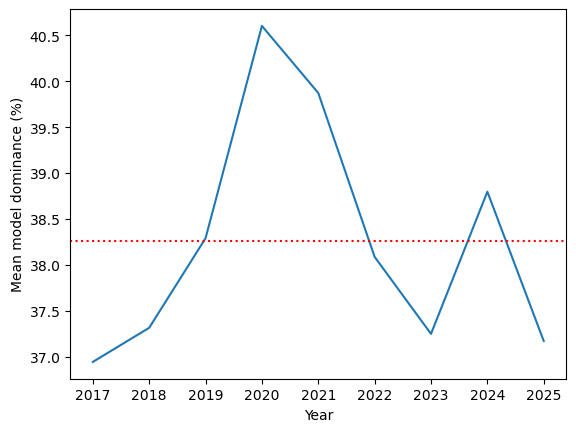

In [16]:
plt.plot(years, dominances)

plt.xlabel("Year")
plt.ylabel("Mean model dominance (%)")

plt.axhline(np.mean(dominances), linestyle="dotted", color="red")

plt.show()

# **LASSO Stock-wise optimality**

In [10]:
optimal_parameters = {}
with open("LASSO/LASSO_StockWise.txt") as file:
    for i in file.readlines():
        data = i.split()
        optimal_parameters[data[0]] = float(data[1])

In [ ]:
performance_tracker = {}
performance_simple = {}
model_dominance = {}

for ticker in tickers["Ticker"]:
    Stock_Data = pd.read_sql(f"SELECT * FROM StockData WHERE Ticker='{ticker}' AND Date>='2017-09-14'", con=StockDataDatabase, parse_dates=["Date"])
    
    Stock_Data = pd.merge(Stock_Data, TrainingDataFrame, left_on="Date", right_on="Date")

    Stock_Data["Target"] = Stock_Data["Close"]
    Stock_Data = Stock_Data.dropna().reset_index(drop=True)

    training_length = 4 # Days
    prediction_length = 1 # Days

    performance_tracker[ticker] = []
    performance_simple[ticker] = []
    model_dominance[ticker] = []

    MAPEs = []
    AccuracyToSimple = []
    dominance_dates = []
    for window_start in range(len(Stock_Data) - (training_length + prediction_length)):
        if window_start + training_length + prediction_length > len(TrainingDataFrame):
            continue
            
        scaler = StandardScaler()

        Training_Features = scaler.fit_transform(TrainingDataFrame[historic_columns].iloc[window_start:window_start+training_length])
        Training_Target = Stock_Data["Target"].iloc[window_start:window_start+training_length]
    
        Test_Features = scaler.transform(TrainingDataFrame[historic_columns].iloc[window_start+training_length:window_start+training_length+prediction_length])
        Test_Target = Stock_Data["Target"].iloc[window_start+training_length:window_start+training_length+prediction_length]

        MODEL = Lasso(alpha=optimal_parameters[ticker])

        MODEL.fit(Training_Features, Training_Target)
    
        prediction = MODEL.predict(Test_Features)
        
        AccuracyToSimple.append(mean_absolute_percentage_error(Test_Target, prediction) <= (mean_absolute_percentage_error(Test_Target, [Training_Target.iloc[-1]])))
        MAPEs.append(100*mean_absolute_percentage_error(Test_Target, prediction))
        
        if mean_absolute_percentage_error(Test_Target, prediction) <= mean_absolute_percentage_error(Test_Target, [Training_Target.iloc[-1]]):
            dominance_dates.append(str(Stock_Data["Date"].iloc[window_start+training_length+prediction_length].date()))                                                        

        print(ticker, 100*mean_absolute_percentage_error(Test_Target, prediction))    
    
    performance_simple[ticker] = AccuracyToSimple.copy()
    performance_tracker[ticker] = MAPEs.copy()
    model_dominance[ticker] = dominance_dates.copy()

In [12]:
means_prevalences = [np.mean(i) for i in performance_simple.values()]
np.mean(means_prevalences)
# 0.444066099148723

np.float64(0.35806016717383765)

In [13]:
performance_tracker = pd.DataFrame(performance_tracker).astype("float")

# MEANS & RANGE Metrics
mean_performances = {}
range_performances = {}
for ticker in tickers["Ticker"]:
    mean_performances[ticker] = np.mean(performance_tracker[ticker])
    range_performances[ticker] = np.max(performance_tracker[ticker]) - np.min(performance_tracker[ticker])

mean_performances = dict(sorted(mean_performances.items(), key=lambda x: x[1]))
range_performances = dict(sorted(range_performances.items(), key=lambda x: x[1]))

In [14]:
np.mean(list(mean_performances.values()))

np.float64(2.27066587724895)

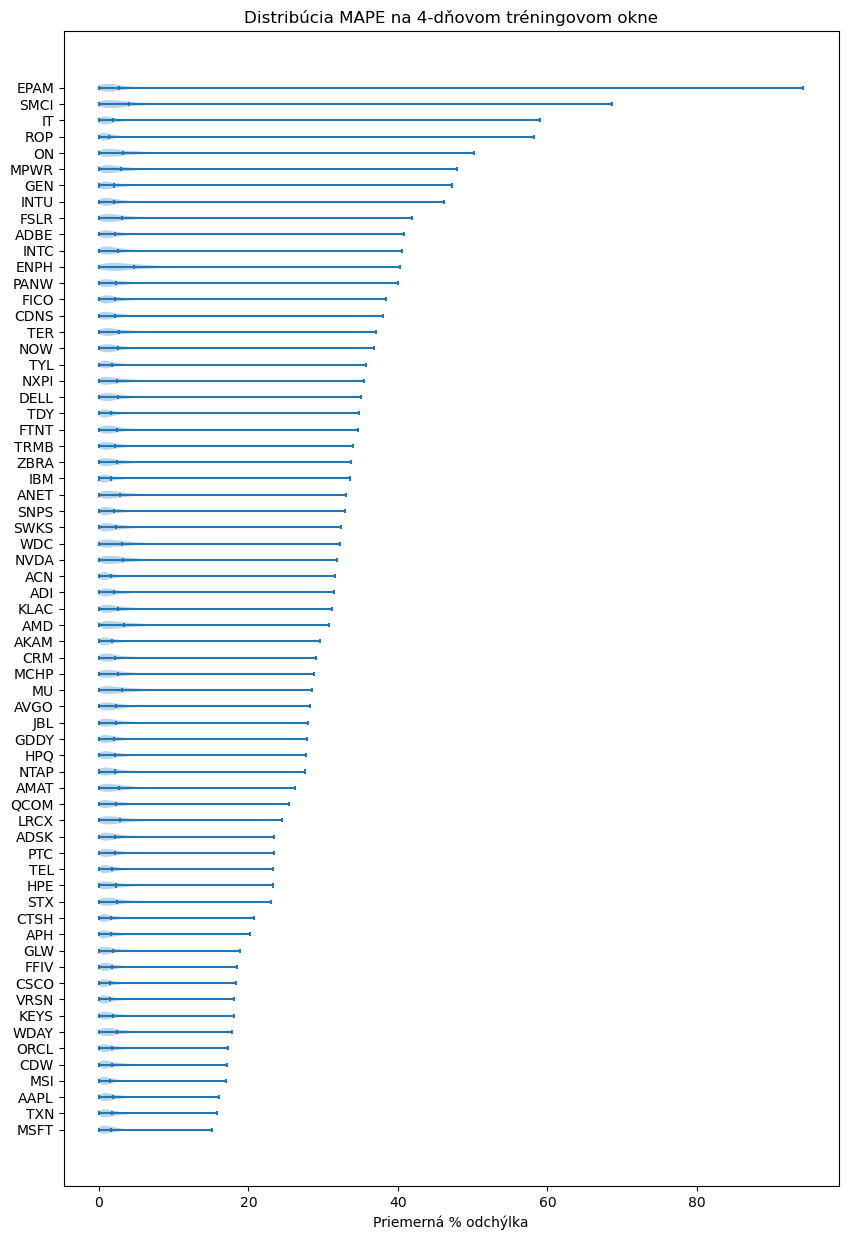

In [10]:
plt.figure(figsize=(10, 15))
plt.violinplot(performance_tracker[list(range_performances.keys())], showmeans=True, orientation="horizontal")

plt.xlabel("Priemerná % odchýlka")
plt.yticks(range(1, 66), list(range_performances.keys()))

plt.title(f"Distribúcia MAPE na {training_length}-dňovom tréningovom okne")

plt.show()